In [1]:
import os
import pandas as pd
import numpy as np 
import seaborn as sns
from tqdm import tqdm
import pickle

from pydub import AudioSegment
from IPython.display import Audio

import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score
import itertools

import warnings
warnings.filterwarnings("ignore")

/var/cache/pypoetry/virtualenvs/app-We1gMlF5-py3.10/lib/python3.10/site-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [2]:
# creating the dataframe which has path to wav file and it's label

df = pd.read_csv('./data/chunks.csv')
df = df[['audio_path', 'label']]
print(df.shape)

(60674, 2)


In [3]:
etiquetas = df['label']
clases, conteo_clases = np.unique(etiquetas, return_counts=True)
weight = dict(zip(clases, np.max(conteo_clases) / conteo_clases))
weight

{0: 2.8002004259050484, 1: 1.0}

In [4]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_index, test_index in sss.split(df['audio_path'], df['label']):
    df_train = df.iloc[train_index]
    df_test = df.iloc[test_index]

In [22]:
X = df_train['audio_path']
y = df_train['label']

X_test = df_test['audio_path']
y_test = df_test['label']

In [6]:
num_clases = y.nunique()

In [7]:
#getting mfcc features for all the data points in test and train

def get_mfcc(path):
    """
    Extracts MFCC (Mel-frequency cepstral coefficients) features from an audio file.

    Parameters:
    path (str): The file path to the audio file.

    Returns:
    numpy.ndarray: A 2D array where each row corresponds to the MFCC features of a frame.
    """
    y, sr = librosa.load(path, sr=None, mono=True)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=10000)
    mfccs = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=40)
    return mfccs.T

In [8]:
def process_audio_files(X, y):
    """
    Processes a list of audio file paths to extract MFCC features and resize them.

    Args:
        X (pd.Series): A pandas Series containing paths to audio files.
        y (pd.Series): A pandas Series containing labels corresponding to the audio files.

    Returns:
        tuple: A tuple containing:
            - X_processed (np.ndarray): A numpy array of processed MFCC features with shape (num_files, 65, 40).
            - y_processed (np.ndarray): A numpy array of labels corresponding to the audio files.
    """
    temp = []
    label = []

    for i in tqdm(range(len(X))):
        audio_path = X.iloc[i]
        mfcc = get_mfcc(audio_path)
        mfcc = np.resize(mfcc, (65, 40,))
        temp.append(mfcc)
        label.append(y.iloc[i])

    X_processed = np.asarray(temp)
    y_processed = np.asarray(label)

    return X_processed, y_processed

In [23]:
%%time

# X_processed, y = process_audio_files(X, y)
# X_test_processed, y_test = process_audio_files(X_test, y_test)

100%|██████████| 18203/18203 [06:08<00:00, 49.35it/s]


CPU times: user 17min 19s, sys: 27min 17s, total: 44min 36s
Wall time: 6min 9s


In [25]:
# with open('X_processed.pkl', 'wb') as f:
#     pickle.dump(X_processed, f)
    
# with open('y_train.pkl', 'wb') as f:
#     pickle.dump(y, f)

# with open('X_test_processed.pkl', 'wb') as f:
#     pickle.dump(X_test_processed, f)
    
# with open('y_test.pkl', 'wb') as f:
#     pickle.dump(y_test, f)

In [11]:
with open('X_processed.pkl', 'rb') as f:
    X_processed = pickle.load(f)

with open('y_train.pkl', 'rb') as f:
    y = pickle.load(f)

with open('X_test_processed.pkl', 'rb') as f:
    X_test_processed = pickle.load(f)
    
with open('y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

In [12]:
print(f'El conjunto de entrenamiento tiene la forma {X_processed.shape}')
print(f'Los labels del conjunto de entrenamiento tiene la forma {y.shape}')

El conjunto de entrenamiento tiene la forma (42471, 65, 40)
Los labels del conjunto de entrenamiento tiene la forma (42471,)


#### Modelling

In [13]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import keras.backend as K

tf.keras.backend.clear_session()

2024-10-14 15:38:28.394031: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-14 15:38:28.417063: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-14 15:38:28.424086: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-14 15:38:28.441400: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [14]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


I0000 00:00:1728934716.459432    3034 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1728934716.514491    3034 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1728934716.514826    3034 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [15]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
# Add attention layer to the deep learning network
class Attention(layers.Layer):
    """
    Custom Keras Layer implementing an Attention mechanism.

    Methods
    -------
    build(input_shape)
        Initializes the weights and biases for the attention mechanism.
    
    call(x)
        Applies the attention mechanism to the input tensor `x` and returns the context vector.

    Parameters
    ----------
    input_shape : tuple
        Shape of the input tensor.
    
    x : tensor
        Input tensor to which the attention mechanism is applied.

    Returns
    -------
    tensor
        Context vector obtained after applying the attention mechanism.
    """
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), 
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), 
                                 initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # Alignment scores. Pass them through tanh function
        e = tf.tanh(tf.matmul(x, self.W) + self.b)  # Cambiado K.dot por tf.matmul
        # Remove dimension of size 1
        e = tf.squeeze(e, axis=-1)  # Cambiado K.squeeze por tf.squeeze
        # Compute the weights
        alpha = tf.nn.softmax(e)  # Cambiado K.softmax por tf.nn.softmax
        # Reshape to tensorFlow format
        alpha = tf.expand_dims(alpha, axis=-1)  # Cambiado K.expand_dims por tf.expand_dims
        # Compute the context vector
        context = x * alpha
        context = tf.reduce_sum(context, axis=1)  # Cambiado K.sum por tf.reduce_sum
        return context

In [17]:
#Create model

#input
input = layers.Input(shape=(65,40), name='input_layer')

#cnn
x = layers.Conv1D(256, (3,), activation='relu')(input)
x = layers.BatchNormalization()(x)
x = layers.Conv1D(128, (3,), activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv1D(64, (3,), activation='relu')(x)
x = layers.BatchNormalization()(x)
#lstm
x = layers.LSTM(256, return_sequences = True)(x)
x = layers.Dropout(0.5)(x)
x = layers.LSTM(128, return_sequences = True)(x)
x = layers.Dropout(0.5)(x)
x = layers.LSTM(64, return_sequences = True)(x)
x = layers.Dropout(0.5)(x)
x = Attention()(x)
#dense
x = layers.Dense(256,'relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128,'relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64,'relu')(x)
x = layers.Dropout(0.5)(x)

#output
output = layers.Dense(num_clases, activation='softmax', name='output_layer')(x)

model = Model(inputs=input, outputs=output)
model.summary()

I0000 00:00:1728934716.557301    3034 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1728934716.557604    3034 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1728934716.557862    3034 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1728934716.712399    3034 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 65, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 63, 256)        │        30,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 59, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 59, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 59, 256)        │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 59, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 59, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 59, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 59, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 64)             │           123 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,117 (3.01 MB)

 Trainable params: 788,221 (3.01 MB)

 Non-trainable params: 896 (3.50 KB)

In [18]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'model_weights_mfcc.weights.h5',  
    monitor='val_loss',
    mode='min',
    verbose=1,
    save_weights_only=True,  # guardar solo los pesos
    save_best_only=True,     # guardar solo el mejor modelo
)

# Callback para TensorBoard
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir='logs',
    histogram_freq=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=10, 
    min_lr=0.00001)

# Callback para EarlyStopping
early_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=50,
    mode='min'
)

callbacks = [checkpoint_cb, tensorboard_cb, early_callback, reduce_lr]

In [19]:
#model.load_weights('model_weights_mfcc-v3.weights.h5')

# Paso 3: Compilar el modelo (opcional)
#model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
#compile
ls = tf.keras.losses.SparseCategoricalCrossentropy()
adam = tf.keras.optimizers.Adam()
model.compile(adam, ls, metrics=['accuracy'])

#fitting
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=42)

for train_index, val_index in sss.split(np.zeros(X_processed.shape[0]), y):
    X_train, X_val = X_processed[train_index], X_processed[val_index]
    y_train_split, y_val = y[train_index], y[val_index] 

    # Entrenamiento del modelo
    history = model.fit(
        X_train, y_train_split, 
        validation_data=(X_val, y_val),
        epochs=200,
        callbacks=[callbacks],
        class_weight=weight,
       )

Epoch 1/200


2024-10-14 15:38:46.149203: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
W0000 00:00:1728934726.233362    3084 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934726.313248    3084 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934726.313737    3084 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934726.323527    3084 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934726.323943    3084 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934726.324384    3084 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934726.324788    3084 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934726.325873    3084 gpu_t

930/930 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5751 - loss: 1.0017

W0000 00:00:1728934747.546194    3081 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934747.546606    3081 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934747.546919    3081 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934747.547321    3081 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934747.547784    3081 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934747.548186    3081 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934747.548617    3081 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934747.549067    3081 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934747.549509    3081 gp


Epoch 1: val_loss improved from inf to 0.57565, saving model to model_weights_mfcc.weights.h5


W0000 00:00:1728934750.620455    3086 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934750.620891    3086 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934750.621271    3086 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934750.621684    3086 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934750.622159    3086 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934750.622542    3086 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934750.622948    3086 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934750.623342    3086 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728934750.623789    3086 gp

930/930 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - accuracy: 0.5751 - loss: 1.0017 - val_accuracy: 0.7155 - val_loss: 0.5756 - learning_rate: 0.0010
Epoch 2/200
930/930 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7001 - loss: 0.8735
Epoch 2: val_loss improved from 0.57565 to 0.55467, saving model to model_weights_mfcc.weights.h5
930/930 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.7001 - loss: 0.8735 - val_accuracy: 0.7321 - val_loss: 0.5547 - learning_rate: 0.0010
Epoch 3/200
928/930 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7386 - loss: 0.7987
Epoch 3: val_loss improved from 0.55467 to 0.44719, saving model to model_weights_mfcc.weights.h5
930/930 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.7387 - loss: 0.7986 - val_accuracy: 0.7991 - val_loss: 0.4472 - learning_rate: 0.0010
Epoch 4/200
929/930 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7803 - loss: 0.6951
Epoch 4: val_loss did not improve from 0.44719
930/930 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.7803 - 

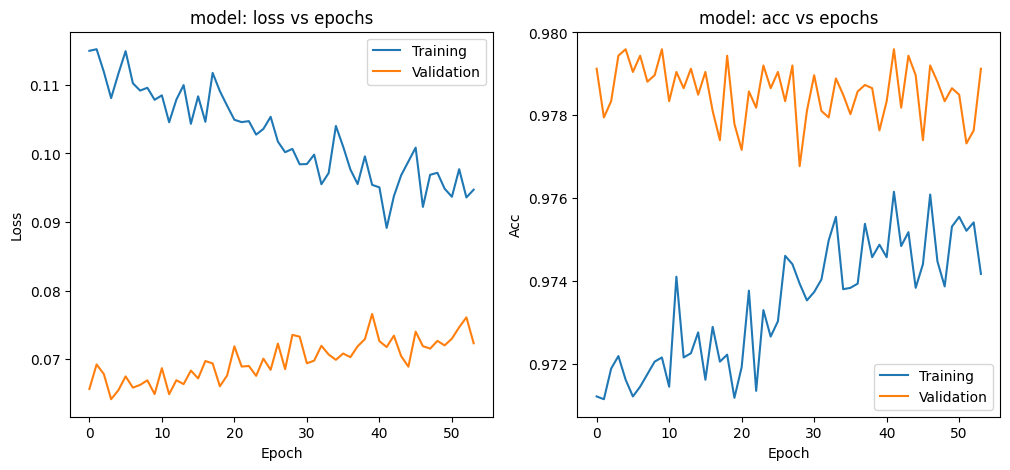

In [21]:
fig = plt.figure(figsize=(12, 5))
fig.add_subplot(121)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model: loss vs epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

fig.add_subplot(122)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model: acc vs epochs')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

#### Predictions

In [28]:
preds = model.predict(X_test_processed)
model.evaluate(X_test_processed, y_test)

569/569 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
569/569 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9417 - loss: 0.2419


[0.23078401386737823, 0.9436905980110168]

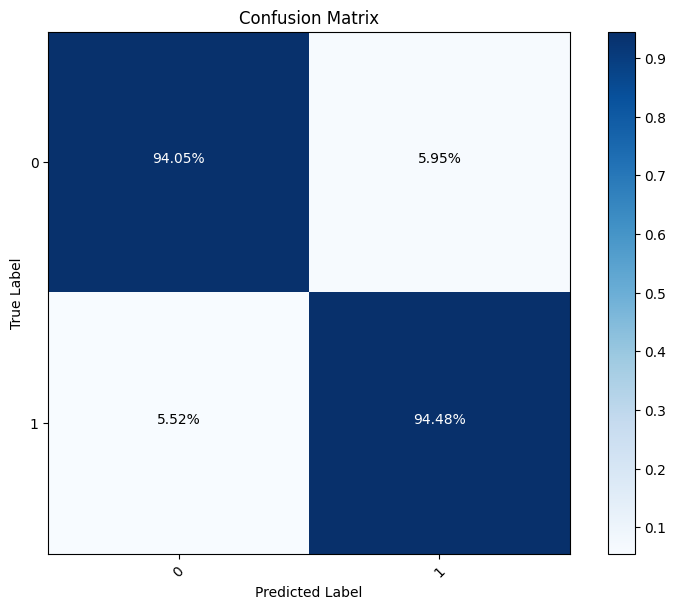

In [41]:
cm = confusion_matrix(y_test, np.argmax(preds, axis=1))

# Número de clases
num_classes = cm.shape[0]

# Normalizar la matriz de confusión
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Graficar
plt.figure(figsize=(8, 6))  # Opcional, para ajustar el tamaño de la figura
plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, range(num_classes), rotation=45)
plt.yticks(tick_marks, range(num_classes))

# Anotar la matriz
for i, j in itertools.product(range(cm_normalized.shape[0]), range(cm_normalized.shape[1])):
    plt.text(j, i, f"{cm_normalized[i, j]:.2%}",
             horizontalalignment="center",
             color="white" if cm_normalized[i, j] > 0.5 else "black")

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [33]:
roc_auc_score(y_test, np.argmax(preds, axis=1))

0.9426653433625528

In [34]:
accuracy_score(y_test, np.argmax(preds, axis=1))

0.9436906004504751

In [40]:
print(classification_report(y_test, np.argmax(preds, axis=1)))

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      4790
           1       0.98      0.94      0.96     13413

    accuracy                           0.94     18203
   macro avg       0.92      0.94      0.93     18203
weighted avg       0.95      0.94      0.94     18203

